In [1]:
# RCF + cellulosic ethanol without dilute-acid pretreatment

from lignin_saf.ligsaf_chemicals import create_chemicals
from lignin_saf.settings.process_params import feed_parameters, solvolysis_params, hydrogenolysis_params, rcf_oil_yield, additional_rcf
from lignin_saf.settings.prices import prices,  _feedstock_price_dry_ton, kg_per_ton, h2_price
from lignin_saf.settings.tea_params import operating_days, labor
from lignin_saf.systems.rcf import create_rcf_system
from lignin_saf.systems.cellulosic_ethanol_no_preatreatment import create_cellulosic_ethanol_system
from lignin_saf.cellulosic_tea import create_cellulosic_ethanol_tea

from lignin_saf.ligsaf_units import HydrogenStorageTank


from biosteam import main_flowsheet as F
import biosteam as bst

chems = create_chemicals()
bst.settings.set_thermo(chems)
bst.settings.CEPCI = 840

chems.define_group(
    name='Poplar',
    IDs=['Glucan', 'Xylan', 'Arabinan', 'Mannan', 'Galactan',
         'Sucrose', 'Lignin', 'Acetate', 'Extract', 'Ash'],
    composition=[0.464, 0.134, 0.002, 0.037, 0.014,
                 0.001, 0.285, 0.035, 0.016, 0.012],
    wt=True
)

poplar_in = bst.Stream('Poplar_In',
                       Poplar=feed_parameters['flow'] * 1e3,
                       Water=feed_parameters['moisture'] * feed_parameters['flow'] * 1e3,
                       phase='l', units='kg/d', price=prices['Feedstock'])

# ── Area 200: RCF process ──────────────────────────────────────────────────
rcf_system = create_rcf_system(ins=poplar_in)
rcf_system.simulate()


# ── Cellulosic ethanol — Carbohydrate_Pulp feeds directly into fermentation ─
etoh_system = create_cellulosic_ethanol_system(ins=F.Carbohydrate_Pulp)
etoh_system.simulate()

# No pretreatment_wastewater — only S401 stillage filtrate goes to WWT.
etoh_ww     = [F.unit.S401.outs[1]]
etoh_solids = [F.unit.S401.outs[0]]

# ── WWT: RCF wastewater + ethanol stillage filtrate ────────────────────────
WWT = bst.create_conventional_wastewater_treatment_system(
    'WWT',
    ins=[F.RCF_WW_OUTS] + etoh_ww,
)
for unit in WWT.units:
    if hasattr(unit, 'strict_moisture_content'):
        unit.strict_moisture_content = False

# Wire WWT RO-treated water to PWC; create_all_facilities(WWT=False) leaves
# M2 (placeholder mixer) empty, so PWC would otherwise buy ~480,000 kg/hr
# of fresh water unnecessarily.
F.unit.PWC.ins[0] = WWT.outs[2]

solids_to_BT = bst.Mixer('MIX_BT_solids', ins=[WWT.outs[1]] + etoh_solids)
gas_mixer    = bst.Mixer('MIX_BT_gas',    ins=[F.RCF_PSAWASTE_OUTS, WWT.outs[0]])

BT = bst.facilities.BoilerTurbogenerator('BT', fuel_price=prices['CH4'])
BT.ins[0] = solids_to_BT.outs[0]
BT.ins[1] = gas_mixer.outs[0]



h2_rcf = bst.Stream()
h2_rcf.copy_like(F.RCF_H2_IN)

shared_h2_storage = HydrogenStorageTank('H2_TK', ins=h2_rcf)



rcf_etoh_system = bst.System(
    'RCF_ETOH_system',
    path=(rcf_system, etoh_system, WWT),
    facilities=[solids_to_BT, gas_mixer, BT, shared_h2_storage],
)

rcf_etoh_system.simulate()
integrated_tea = create_cellulosic_ethanol_tea(rcf_etoh_system)
F.ethanol.price = 0.76


F.cellulase.price = prices['Cellulase'] 
F.CSL.price = prices ['CSL'] 
F.DAP.price = prices['DAP'] 
F.caustic.price = prices['Caustic']
F.denaturant.price =  prices['Denaturant'] 
F.cooling_tower_chemicals.price = prices['CT_chemicals'] 


#print(f'The MSP for RCF crude oil is  {round(integrated_tea.solve_price(F.RCF_CRUDE_OUT), 3)} USD/kg')



c:\Users\hwadg\anaconda3\envs\pyfuel\lib\site-packages\thermosteam\equilibrium\bubble_point.py:128: RuntimeWarning: Hydrogen has no defined Dortmund groups; functional group interactions are ignored
  self.gamma = thermo.Gamma(chemicals)
c:\Users\hwadg\anaconda3\envs\pyfuel\lib\site-packages\thermosteam\equilibrium\bubble_point.py:128: RuntimeWarning: Methane has no defined Dortmund groups; functional group interactions are ignored
  self.gamma = thermo.Gamma(chemicals)
c:\Users\hwadg\anaconda3\envs\pyfuel\lib\site-packages\thermosteam\equilibrium\dew_point.py:129: RuntimeWarning: Methane has no defined Dortmund groups; functional group interactions are ignored
  self.gamma = thermo.Gamma(chemicals)
c:\Users\hwadg\anaconda3\envs\pyfuel\lib\site-packages\biosteam\units\_pump.py:224: RuntimeWarning: <Pump: RCF_PUMP1> no pump type available at current power (2.45e+03 hp), head (3.35e+03 ft), kinematic viscosity (6.09e-07 m2/s), and NPSH (0.745 ft); assuming centrigugal pump
  warn(f'{repr

In [2]:
# Labor cost from [1]
# [1] W. Seider et al., Product and Process Design Principles. 2016. John Wiley & Sons.
# Table 17.3 from [1]
# For RCF - 6 operators for the reactors (solids-fluids processing, and > 100 ton/day so 3 x 2 =6 ), and 2 for the distillation columns downstream for solvent recovery. Total operators: 8
# For ethanol production, 6 operators for reactors as solids-fluids processing and large volumes so 3 x 2 = 6, and then 2 for the beer column downstream for ethanol purification. Total operators: 8
# 1 operators for the storage. Total operators: 1
# 1 operators for WWT (I think complexity of feed streams), and 1 for BT. Total operator: 2
# Total operators per shift: 19

num_operators_per_shift = 19
num_shifts              = 5       # number of operator shifts (4 working + 1 relief)
pay_rate                = 40      # [USD/hr] operator base pay rate

DWandB             = num_operators_per_shift * num_shifts * 2080 * pay_rate
Dsalaries_benefits = 0.15 * DWandB          # 15% of DW&B for salaried staff + benefits
O_supplies         = 0.06 * DWandB          # 6% of DW&B for operating supplies
technical_assistance = 5 * 75_000           # 5 technical staff @ $75,000/yr
control_lab          = 5 * 80_000           # 5 lab/QC staff  @ $80,000/yr

labor = DWandB + Dsalaries_benefits + O_supplies + technical_assistance + control_lab
# [USD/yr] total annual labor cost; passed to tea.labor_cost after creating the TEA object

In [3]:
integrated_tea.operating_days = 330
integrated_tea.labor_cost = labor

In [4]:

msp = round((integrated_tea.solve_price(F.RCF_CRUDE_OUT)),2)
print(f'The MSP for RCF crude is  {msp} USD/kg')

The MSP for RCF crude is  1.38 USD/kg


In [5]:
break

SyntaxError: 'break' outside loop (668683560.py, line 1)

In [6]:
model = bst.Model(rcf_etoh_system)

In [7]:
from chaospy import distributions as shape
param = model.parameter

In [8]:

var_50 = 0.5 # 50% variation in parameters - set for a few
var_20 = 0.2 # 20% variation in other parameters

In [9]:
# Operating days — kind='isolated': only affects TEA time scaling, not mass/energy balance
dist = shape.Uniform(lower = 297 , upper = 363)
@param(name = 'Operating days',
    element = 'Overall',
    kind = 'isolated',
    units = 'days',
    baseline = integrated_tea.operating_days,
    distribution = dist)
def set_opertaing_days(i):
    integrated_tea.operating_days = i


# Poplar feedstock
dist = shape.Uniform(lower = 50 , upper = 100)
@param(name = 'Poplar feedstock price',
    element = 'Overall',
    kind = 'isolated',
    units = 'USD/DMT',
    baseline = _feedstock_price_dry_ton,
    distribution = dist)
def set_poplar_feedstock_price(i):
    # i is in USD/dry short ton; stream price must be USD/kg wet biomass
    F.Poplar_In.price = i / kg_per_ton / (1 + feed_parameters['moisture'])



# Labor cost
dist = shape.Uniform(lower = integrated_tea.labor_cost * (1-var_50) , upper = integrated_tea.labor_cost * (1+var_50) )
@param(name = 'Labor cost',
    element = 'Overall',
    kind = 'isolated',
    units = 'USD/yr',
    baseline = integrated_tea.labor_cost,
    distribution = dist)
def set_labor_cost(i): 
    integrated_tea.labor_cost = i


# Electricity price
dist = shape.Triangle(lower = 0.0641, midpoint = bst.settings.electricity_price, upper = 0.1798) 
@param(name = 'Electricity cost',
    element = 'Overall', 
    kind = 'isolated',
    units = 'USD/kWh',
    baseline = bst.settings.electricity_price, distribution = dist)
def set_electricity_price(i):
    bst.settings.electricity_price = i  



# Hydrogen price
dist = shape.Triangle(lower = 2.74 , midpoint=3.70, upper = 11.53)
@param(name = 'Hydrogen price',
       element = 'Overall',
       kind = 'isolated',
       units = 'USD/kg',
       baseline =  h2_price,
       distribution = dist)
def set_hydrogen_price(i):
    F.RCF_H2_IN.price = i


# Hydrogen storage time
dist = shape.Uniform(lower = 0.25 , upper = 3)
@param(name = 'Hydrogen storage period',
       element = 'Overall',
       kind = 'isolated',
       units = 'days',
       baseline =  F.H2_TK.storage_period,
       distribution = dist)
def set_h2_storage_period(i):
    F.H2_TK.storage_period = i
    F.H2_TK.simulate()   # re-runs _design()/_cost() so CAPEX updates for solve_price()


In [11]:
# Solvolysis pressure
dist = shape.Uniform(lower = solvolysis_params['P'],  upper = 83.3e5)
@param(name = 'Solvolysis reactor pressure',
    element = 'RCF', 
    kind = 'coupled',
    units = 'Pa',
    baseline = solvolysis_params['P'], distribution = dist)
def set_solvolysis_rxr_pressure(i):
    F.RCF_RXR1.P = i  



# Solvolysis reaction time
dist = shape.Triangle(lower = 3*(1-var_50), midpoint = 3, upper = 3*(1+var_50))
@param(name = 'Solvolysis reaction time',
    element = 'RCF', 
    kind = 'coupled',
    units = 'hr',
    baseline = solvolysis_params['tau_s'], distribution = dist)
def set_solvolysis_reaction_time(i):
    F.RCF_RXR1.tau = i      


# Solvolysis residence time
dist = shape.Triangle(lower = 9/60, midpoint = solvolysis_params['tau_s_res'], upper = 36/60) 
@param(name = 'Solvolysis residence time',
    element = 'RCF', 
    kind = 'coupled',
    units = 'hr',
    baseline = solvolysis_params['tau_s_res'], distribution = dist)
def set_solvolysis_residence_time(i):
    F.RCF_RXR1.tau_residence = i  


# Solvolysis cleaning time
dist = shape.Triangle(lower = 0.5, midpoint = 1, upper = 2) 
@param(name = 'Solvolysis cleaning time',
    element = 'RCF', 
    kind = 'coupled',
    units = 'hr',
    baseline = F.RCF_RXR1.tau_0, distribution = dist)
def set_solvolysis_cleaning_time(i):
    F.RCF_RXR1.tau_0 = i  


# Methanol price
dist = shape.Triangle(lower = 0.2648, midpoint = F.RCF_MEOH_IN.price, upper = 0.3972)
@param(name = 'Methanol cost',
    element = 'RCF', 
    kind = 'isolated',
    units = 'USD/kg',
    baseline = F.RCF_MEOH_IN.price, distribution = dist)
def set_methanol_price(i):
    F.RCF_MEOH_IN.price = i  

# Solvent losses in pulp
dist = shape.Uniform(lower=0.005, upper=0.05)
@param(name='RCF solvent losses',
       element='RCF',
       kind='coupled',
       units='-',
       baseline=solvolysis_params['solvent_losses'],
       distribution=dist)
def set_solvent_losses(i):
    solvolysis_params['solvent_losses'] = i

# RCF reactor duty
dist = shape.Uniform(lower=49, upper=72)
@param(name='RCF reactor duty',
       element='RCF',
       kind='coupled',
       units='-',
       baseline=hydrogenolysis_params['duty'],
       distribution=dist)
def set_rcf_reactor_duty(i):
    hydrogenolysis_params['duty'] = i


# RCF catalyst cost 
dist = shape.Uniform(lower = F.RCF_CAT_IN.price * (0.1), upper = F.RCF_CAT_IN.price * (10) )  # Same variation as Bartling et al
@param(name = 'RCF catalyst price',
    element = 'RCF', 
    kind = 'isolated',
    units = 'USD/kg',
    baseline = F.RCF_CAT_IN.price, distribution = dist)
def set_rcf_catalyst_price(i):
    F.RCF_CAT_IN.price = i      



# RCF catalyst lifetime 
dist = shape.Uniform(lower = 1, upper = 36)  # Same as Bartling et al
@param(name = 'RCF catalyst lifetime',
    element = 'RCF', 
    kind = 'isolated',
    units = 'months',
    baseline = solvolysis_params['cat_lifetime'], distribution = dist)
def set_rcf_catalyst_lifetime(i):
    solvolysis_params['cat_lifetime'] = i
    F.RCF_CAT_IN.imass['NiC'] = (
        solvolysis_params['cat_loading'] * (feed_parameters['flow'] * 1e3 / 24) * solvolysis_params['tau_h']
    ) / (i * 30 * 24)   # [kg/hr]


# RCF catalyst loading 
dist = shape.Uniform(lower = solvolysis_params['cat_loading'] * (1-var_50) , upper = solvolysis_params['cat_loading'] * (1+var_50) ) 
@param(name = 'RCF catalyst loading',
    element = 'RCF', 
    kind = 'isolated',
    units = 'kg/kg-biomass',
    baseline = solvolysis_params['cat_loading'], distribution = dist)
def set_rcf_catalyst_loading(i):
    solvolysis_params['cat_loading'] = i 
    F.RCF_CAT_IN.imass['NiC'] = (
        i * (feed_parameters['flow'] * 1e3 / 24) * solvolysis_params['tau_h']
    ) / (solvolysis_params['cat_lifetime'] * 30 * 24)   # [kg/hr]

# Cellulose retention
dist = shape.Triangle(lower=0.8, midpoint = solvolysis_params['Cellulose_retention'], upper=1.0)
@param(name='Cellulose retention',
       element='RCF',
       kind='coupled',
       units='%',
       baseline=solvolysis_params['Cellulose_retention'],
       distribution=dist)
def set_cellulose_retention(i):
    solvolysis_params['Cellulose_retention'] = i


# Xylose retention
dist = shape.Triangle(lower=0.2, midpoint = solvolysis_params['Xylose_retention'], upper=1.0)
@param(name='Xylose retention',
       element='RCF',
       kind='coupled',
       units='%',
       baseline=solvolysis_params['Xylose_retention'],
       distribution=dist)
def set_xylose_retention(i):
    solvolysis_params['Xylose_retention'] = i


# Delignification
dist = shape.Triangle(lower = 0.4 , midpoint = solvolysis_params['Delignification'], upper = 0.9)
@param(name = 'Delignfication',
       element = 'RCF',
       kind = 'coupled',
       units = '%',
       baseline = solvolysis_params['Delignification'], distribution = dist)
def set_delignfication(i):
    solvolysis_params['Delignification'] = i
    F.RCF_RXR1.reaction_1.X = i   


# Condensation extent
dist = shape.Triangle(lower = 0.001 , midpoint = hydrogenolysis_params['condensation_extent'], upper = 0.709)
@param(name = 'Condensation extent',
       element = 'RCF',
       kind = 'coupled',
       units = '%',
       baseline = hydrogenolysis_params['condensation_extent'], distribution = dist)
def set_condensation_extent(i):
    _X_scale = 1.0 - 1e-6
    hydrogenolysis_params['condensation_extent'] = i
    # X values are baked into the ParallelReaction at create_rcf_system() time; must update directly.
    # Reactions 0 & 1: Propylguaiacol/Propylsyringol (monomers that escaped condensation).
    # Reactions 4 & 5: S_Oligomer/G_Oligomer (baseline oligomers + condensed monomer fraction).
    F.RCF_RXR2.reaction[0].X = _X_scale * rcf_oil_yield['Monomers'] * 0.5 * (1 - i)
    F.RCF_RXR2.reaction[1].X = _X_scale * rcf_oil_yield['Monomers'] * 0.5 * (1 - i)
    F.RCF_RXR2.reaction[4].X = _X_scale * (rcf_oil_yield['Oligomers'] * 0.5 + rcf_oil_yield['Monomers'] * 0.5 * i)
    F.RCF_RXR2.reaction[5].X = _X_scale * (rcf_oil_yield['Oligomers'] * 0.5 + rcf_oil_yield['Monomers'] * 0.5 * i)


# Distillation col 1 light key recovery at the top
dist = shape.Uniform(lower = 0.7, 
                     upper = 0.9999) 
@param(name = 'Light key recovery - column 1',
    element = 'RCF', 
    kind = 'coupled',
    units = 'wt%',
    baseline = additional_rcf['rcf_col_1_light_dist_recovery'], distribution = dist)
def set_light_key_recovery_column_1(i):
    additional_rcf['rcf_col_1_light_dist_recovery'] = i
    F.unit.RCF_COL1.Lr = i



In [ ]:
## Distillation col 1 light key recovery at the top
#dist = shape.Uniform(lower = 0.7, 
#                     upper = 0.9999) 
#@param(name = 'Light key recovery - column 1',
#    element = 'RCF', 
#    kind = 'coupled',
#    units = 'wt%',
#    baseline = additional_rcf['rcf_col_1_light_dist_recovery'], distribution = dist)
#def set_light_key_recovery_column_1(i):
#    additional_rcf['rcf_col_1_light_dist_recovery'] = i
#    F.unit.RCF_COL1.Lr = i
#
#
## Distillation col 1 heavy key recovery at the bottom
#dist = shape.Uniform(lower = 0.0001, 
#                     upper = 0.3) 
#@param(name = 'Heavy key recovery - column 1',
#    element = 'RCF', 
#    kind = 'coupled',
#    units = 'wt%',
#    baseline = additional_rcf['rcf_col_1_heavy_bottom_recovery'], distribution = dist)
#def set_heavy_key_recovery_column_1(i):
#    additional_rcf['rcf_col_1_heavy_bottom_recovery'] = i
#    F.unit.RCF_COL1.Hr = i
#
#
## Distillation col 1 k value
#dist = shape.Uniform(lower = 0.0001, 
#                     upper = 10) 
#@param(name = 'Ratio of reflux to minimum reflux-  column 1',
#    element = 'RCF', 
#    kind = 'coupled',
#    units = '-',
#    baseline = additional_rcf['rcf_col_1_k'], distribution = dist)
#def set_k_column_1(i):
#    additional_rcf['rcf_col_1_k'] = i
#    F.unit.RCF_COL1.k = i
#
#
## Distillation col 2 heavy key recovery at the bottom
#dist = shape.Uniform(lower = 0.7, 
#                     upper = 0.9999) 
#@param(name = 'Light key mole fraction at top - column 2',
#    element = 'RCF', 
#    kind = 'coupled',
#    units = 'wt%',
#    baseline = additional_rcf['rcf_col_2_mol_frac_light_top'], distribution = dist)
#def set_light_key_mol_fraction_top(i):
#    additional_rcf['rcf_col_2_mol_frac_light_top'] = i
#    F.unit.RCF_COL2.y_top  = i
#
## Distillation col 2 light key mole fraction at the bottom
#dist = shape.Uniform(lower = 0.0001, 
#                     upper = 0.3) 
#@param(name = 'Light key mole fraction at bottom - column 2',
#    element = 'RCF', 
#    kind = 'coupled',
#    units = 'wt%',
#    baseline = additional_rcf['rcf_col_2_mol_frac_light_bottom'], distribution = dist)
#def set_light_key_mol_fraction_bottom(i):
#    additional_rcf['rcf_col_2_mol_frac_light_bottom'] = i
#    F.unit.RCF_COL2.x_bot   = i
#
#
## Distillation col 2 k value
#dist = shape.Uniform(lower = 0.0001, 
#                     upper = 10) 
#@param(name = 'Ratio of reflux to minimum reflux-  column 2',
#    element = 'RCF', 
#    kind = 'coupled',
#    units = '-',
#    baseline = additional_rcf['rcf_col_1_k'], distribution = dist)
#def set_k_column_2(i):
#    additional_rcf['rcf_col_2_k'] = i
#    F.unit.RCF_COL2.k = i
#
#

In [12]:
# Glucose to ethanol conversion
dist = shape.Triangle(lower = 0.8, midpoint = F.R303.cofermentation[0].X, upper = 0.95)
@param(name = 'Glucose to ethanol conv.',
    element = 'EHF', 
    kind = 'coupled',
    units = '-',
    baseline = F.R303.cofermentation[0].X, distribution = dist)
def set_glucose_to_ethanol_conv(i):
    F.R303.cofermentation[0].X = i  

# Glucan to glucose conversion 
dist = shape.Triangle(lower = 0.8, midpoint = F.R303.saccharification[2].X,  upper = 0.9)
@param(name = 'Glucan to glucose conv.',
    element = 'EHF', 
    kind = 'coupled',
    units = '-',
    baseline = F.R303.saccharification[2].X, distribution = dist)
def set_glucan_to_glucose_conv(i):
    F.R303.saccharification[2].X = i  


# Saccharification residence time
dist = shape.Triangle(lower = 60 * (1-var_20), midpoint = F.R303.tau_saccharification, upper = 60 * (1+var_20))
@param(name = 'Saccharification residence time',
    element = 'EHF', 
    kind = 'coupled',
    units = 'hr',
    baseline = F.R303.tau_saccharification, distribution = dist)
def set_saccharification_tau(i):
    F.R303.tau_saccharification = i  

# Cofermentation residence time
dist = shape.Triangle(lower = 36 * (1-var_20),  midpoint = F.R303.tau_cofermentation, upper = 36 * (1+var_20))
@param(name = 'Cofermentation residence time',
    element = 'EHF', 
    kind = 'coupled',
    units = 'hr',
    baseline = F.R303.tau_cofermentation, distribution = dist)
def set_cofermentation_tau(i):
    F.R303.tau_cofermentation = i  


# Xylose to ethanol conversion
dist = shape.Triangle(lower = 0.8, midpoint =  F.R303.cofermentation[4].X, upper = 0.9)
@param(name = 'Xylose to ethanol conv.',
    element = 'EHF', 
    kind = 'coupled',
    units = '-',
    baseline = F.R303.cofermentation[4].X, distribution = dist)
def set_xylose_to_ethanol_conv(i):
    F.R303.cofermentation[4].X = i      

# Xylan to xylose conversion
dist = shape.Triangle(lower=0.8, midpoint = F.unit.R301.reactions[0].X , upper=0.9)
@param(name='Xylan to xylose conversion',
       element='Cellulosic ethanol',
       kind='coupled',
       units='-',
       baseline=F.unit.R301.reactions[0].X,
       distribution=dist)
def set_xylan_to_xylose_conversion(i):
    F.unit.R301.reactions[0].X = i



# Cellulase enzyme loading
dist = shape.Triangle(lower = 0.01, midpoint = F.M301.enzyme_loading, upper = 0.05)
@param(name = 'Cellulase enzyme loading',
    element = 'EHF', 
    kind = 'coupled',
    units = 'wt%',
    baseline = F.M301.enzyme_loading, distribution = dist)
def set_enzyme_loading(i):
    F.M301.enzyme_loading = i  


# Cellulase price
dist = shape.Uniform(lower = F.M301.ins[1].price * (1-var_50), upper = F.M301.ins[1].price * (1+var_50))
@param(name = 'Cellulase price',
    element = 'EHF',
    kind = 'isolated',
    units = 'USD/kg',
    baseline = F.M301.ins[1].price, distribution = dist)
def set_cellulase_price(i):
    F.M301.ins[1].price = i


    


In [ ]:
metric = model.metric
@metric(name='Minimum Jet Selling Price', element='TEA', units='USD/gal')
def get_msp():
    msp = (integrated_tea.solve_price(F.RCF_CRUDE_OUT))
    return msp


In [ ]:
import numpy as np
np.random.seed(3198)
samples = model.sample(N=3000, rule = 'L')  # Change this to 3000 later
model.load_samples(samples)

In [ ]:
model.evaluate()

c:\Users\hwadg\anaconda3\envs\pyfuel\lib\site-packages\biosteam\units\_pump.py:224: RuntimeWarning: <Pump: RCF_PUMP1> no pump type available at current power (2.42e+03 hp), head (3.32e+03 ft), kinematic viscosity (6.96e-07 m2/s), and NPSH (16.6 ft); assuming centrigugal pump
  warn(f'{repr(self)} no pump type available at current power '
c:\users\hwadg\onedrive - the pennsylvania state university\shi_wadgama_shared\models\atjspk\lignin_saf\ligsaf_units.py:410: CostWarning: <SolvolysisReactor: RCF_RXR1> Vertical vessel length (59.67 ft) is out of bounds (12 to 40 ft) for cost correlation
  self._vertical_vessel_design(
c:\users\hwadg\onedrive - the pennsylvania state university\shi_wadgama_shared\models\atjspk\lignin_saf\ligsaf_units.py:659: CostWarning: <HydrogenolysisReactor: RCF_RXR2> Vertical vessel length (41.79 ft) is out of bounds (12 to 40 ft) for cost correlation
  self._vertical_vessel_design(
c:\Users\hwadg\anaconda3\envs\pyfuel\lib\site-packages\biosteam\_unit.py:1241: CostW

In [ ]:
df_rho, df_p = model.spearman_r()
print(df_rho["TEA", "Minimum jet selling price [USD/gal]"])

Element  Parameter                                         
RCF      Light key recovery - column 1 [wt%]                  NaN
         Heavy key recovery - column 1 [wt%]                  NaN
         Ratio of reflux to minimum reflux-  column 1 [-]     NaN
         Light key mole fraction at top - column 2 [wt%]      NaN
         Light key mole fraction at bottom - column 2 [wt%]   NaN
         Ratio of reflux to minimum reflux-  column 2 [-]     NaN
Name: (TEA, Minimum jet selling price [USD/gal]), dtype: float64


In [ ]:
model.table.to_excel('bartling_trial_4.xlsx')

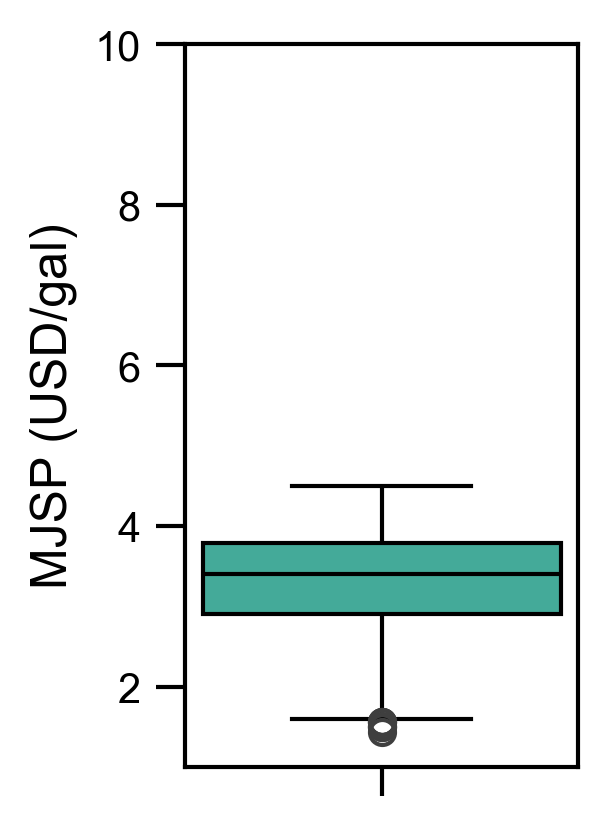

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
plt.rc('font',family='Arial')

msp_values = model.table["TEA", "Minimum jet selling price [USD/gal]"]
msp_df = pd.DataFrame({'MSP ($/gal)': msp_values})
plt.figure(figsize=(1.6937007874, 3.12913386))  # Adjust figure size

# Way to fetch a color palette from seaborn
bugn = sns.color_palette('BuGn', n_colors=6)  # Get 6 shades of blue
light_bugn = bugn[2]
mid_bugn = bugn[4]
dark_bugn = bugn[5]
'''
# Create the violin plot with embedded box plot
sns.violinplot(
    data=msp_df,
    y="MSP ($/gal)",
    inner="box",
    color="#c6dbef",  # Violin body color (HEX)
    linewidth=0
)

'''

sns.boxplot(
    data=msp_df,
    y="MSP ($/gal)",
    width=0.20,
    boxprops={"facecolor": "#44AA99", "edgecolor": 'black', "linewidth": 1},
    medianprops={"color": "black", "linewidth": 1},
    whiskerprops={"color": "black", "linewidth": 1},
    capprops={"color": "black", "linewidth": 1}
)



# Add gray diamond marker at 8.6
ax = plt.gca()
ax.scatter(
    x=0, y=22.08,  # x=0 for single-category violin/box plot
    marker='D',  # Diamond marker
    s=75,       # Size of the marker
    facecolor='lightgray',
    edgecolor='black',
    linewidth=1,
    zorder=10
)


plt.tick_params(axis='both', which='major', labelsize=12, width=1.0, length=7)
# set the axis line width in pixels
ax = plt.gca()  # Get current axes
for axis in ['left', 'bottom', 'top', 'right']:
    ax.spines[axis].set_linewidth(1)
    ax.set_ylim(1, 10)
plt.yticks(fontsize = 10, color = 'black')


# Label the plot
plt.ylabel("MJSP (USD/gal)", fontsize=12, color = 'black')
#plt.title(f'Capacity: {round((saf_stream.F_vol*264.17*24*330)/1e6,1)} MM gal/yr', fontsize=16, color = 'black')
#plt.grid(True, 'major', 'y', linestyle="--", linewidth=1.2, alpha=0.5, color = 'gray')


# Add shaded area from 2.4 to 3 USD/gal
#ax.axhspan(2.4, 3.0, color='#88CCEE', alpha=0.5, zorder=0)

# Add shaded area from 4.4 
#ax.axhspan(4.6, 9.6, color='#DDCC77', alpha=0.5, zorder=0)

# Saving the plot
#plt.savefig("msp_violin_plot.png", dpi=300, bbox_inches="tight")  # PNG format (high quality)
# Show the plot

#plt.savefig("box plot_triangular.png", bbox_inches="tight")
plt.show()

In [ ]:
rcf_etoh_system.empty_outlet_streams()
rcf_etoh_system.empty_recycles()
rcf_etoh_system.reset_cache()
rcf_etoh_system.simulate()   

c:\Users\hwadg\anaconda3\envs\pyfuel\lib\site-packages\biosteam\units\_pump.py:224: RuntimeWarning: <Pump: RCF_PUMP1> no pump type available at current power (2.44e+03 hp), head (3.34e+03 ft), kinematic viscosity (6.35e-07 m2/s), and NPSH (6.74 ft); assuming centrigugal pump
  warn(f'{repr(self)} no pump type available at current power '
c:\users\hwadg\onedrive - the pennsylvania state university\shi_wadgama_shared\models\atjspk\lignin_saf\ligsaf_units.py:410: CostWarning: <SolvolysisReactor: RCF_RXR1> Vertical vessel length (59.67 ft) is out of bounds (12 to 40 ft) for cost correlation
  self._vertical_vessel_design(
c:\users\hwadg\onedrive - the pennsylvania state university\shi_wadgama_shared\models\atjspk\lignin_saf\ligsaf_units.py:659: CostWarning: <HydrogenolysisReactor: RCF_RXR2> Vertical vessel length (41.79 ft) is out of bounds (12 to 40 ft) for cost correlation
  self._vertical_vessel_design(
c:\Users\hwadg\anaconda3\envs\pyfuel\lib\site-packages\biosteam\_unit.py:1241: CostW